# LeetCode #55: Jump Game

https://leetcode.com/problems/jump-game/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **DP** | $O(n^2)$ | $O(n)$ |
| **Greedy maxReach** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### DP
Maintain a boolean array `reachable[i]`. Position i is reachable if any j < i is reachable and `j + nums[j] >= i`. $O(n^2)$ due to the inner scan.

### Optimal: Greedy maxReach ★
Track `maxReach` = the furthest index reachable so far. Scan left to right: if `i > maxReach`, position i is unreachable → return false. Otherwise update `maxReach = max(maxReach, i + nums[i])`. Return true if we complete the loop.

**Why greedy works:** We only care about whether the last index is reachable, not the specific path. The maximum we can reach from any position up to i is what matters.

**Constraints:**
* $1 \leq$ nums.length $\leq 10^4$
* $0 \leq$ nums[i] $\leq 10^5$

## Solutions

### C#

In [ ]:
public class Solution {
    public bool CanJump(int[] nums) {
        int maxReach = 0;
        for (int i = 0; i < nums.Length; i++) {
            if (i > maxReach) return false; // i is unreachable
            maxReach = Math.Max(maxReach, i + nums[i]);
        }
        return true;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def canJump(self, nums: List[int]) -> bool:
        max_reach = 0
        for i, v in enumerate(nums):
            if i > max_reach:
                return False
            max_reach = max(max_reach, i + v)
        return True

### Go

In [ ]:
package main

func canJump(nums []int) bool {
	maxReach := 0
	for i, v := range nums {
		if i > maxReach {
			return false
		}
		if i+v > maxReach {
			maxReach = i + v
		}
	}
	return true
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn can_jump(nums: Vec<i32>) -> bool {
        let mut max_reach = 0usize;
        for (i, &v) in nums.iter().enumerate() {
            if i > max_reach {
                return false;
            }
            max_reach = max_reach.max(i + v as usize);
        }
        true
    }
}

## Example Scenarios

### 1. Common Case — Reachable
**Input:** `nums = [2, 3, 1, 1, 4]`

Walk through: Scan left to right. i=0: `maxReach = max(0, 0+2) = 2`. i=1: `maxReach = max(2, 1+3) = 4`. Since `maxReach = 4 ≥ 4` (last index), return `true`. We don't even need to check i=2,3,4.

**Why tricky:** Happy path — `maxReach` grows quickly. Interviewers use this to confirm the basic greedy mechanism before edge cases.

### 2. Slightly Complex — Zero Trap with Preceding Large Jump
**Input:** `nums = [3, 2, 1, 0, 4]`

Walk through: i=0: `maxReach=3`. i=1: `max(3,3)=3`. i=2: `max(3,3)=3`. i=3: `max(3,3)=3`. i=4: `4 > maxReach(3)` → return `false`. The zero at index 3 is a "black hole" — indices 1,2,3 all converge to `maxReach=3`.

**Why tricky:** Don't just check for individual zeros — the cumulative reach is what matters. `[4,0,0,0,4]` would return `true` because index 0 reaches past the zero. Interviewers check your understanding of collective vs. individual reachability.

### 3. Edge Case: Time Factor — All Ones, $n = 10^4$
**Input:** `nums = [1, 1, 1, ..., 1]` (10,000 elements)

Walk through: Each position adds exactly 1 to reach. `maxReach` advances by 1 per step, just barely reaching index 9,999. DP approach: for each i, scan j=0..i-1 → $O(n^2/2) = 5 \times 10^7$ operations (borderline TLE). Greedy: $O(n) = 10^4$ operations.

**Why tricky:** Worst case for time — every position has exactly enough reach. This separates $O(n^2)$ DP from $O(n)$ greedy. Interviewers test this to verify your solution's complexity.

### 4. Edge Case: Space Factor — Single Large Jump Covers Everything
**Input:** `nums = [100000, 0, 0, ..., 0]` ($n = 10^4$; only first element is non-zero)

Walk through: i=0: `maxReach = 100,000 ≥ 9,999` → can return `true` immediately. DP would allocate a boolean array of 10,000 entries and fill it entirely. Greedy uses 1 integer.

**Why tricky:** DP needs $O(n)$ space to track reachability per index. Greedy tracks one integer — $O(1)$. When `nums[i]` can be up to $10^5$, a single large value makes the entire array reachable, but DP still fills the whole array.

### 5. Almost-Impossible but Plausible — Single Element [0]
**Input:** `nums = [0]`

Walk through: n=1, already at the last index. The loop body never executes (or we immediately see `maxReach ≥ n-1`). Return `true`.

**Why tricky:** The value is 0 but the answer is `true`. This catches two bugs: (1) checking `nums[0] == 0 → false` without considering n=1, and (2) off-by-one in the loop condition. Interviewers love this minimal trap — it tests whether your code naturally handles the boundary.

---

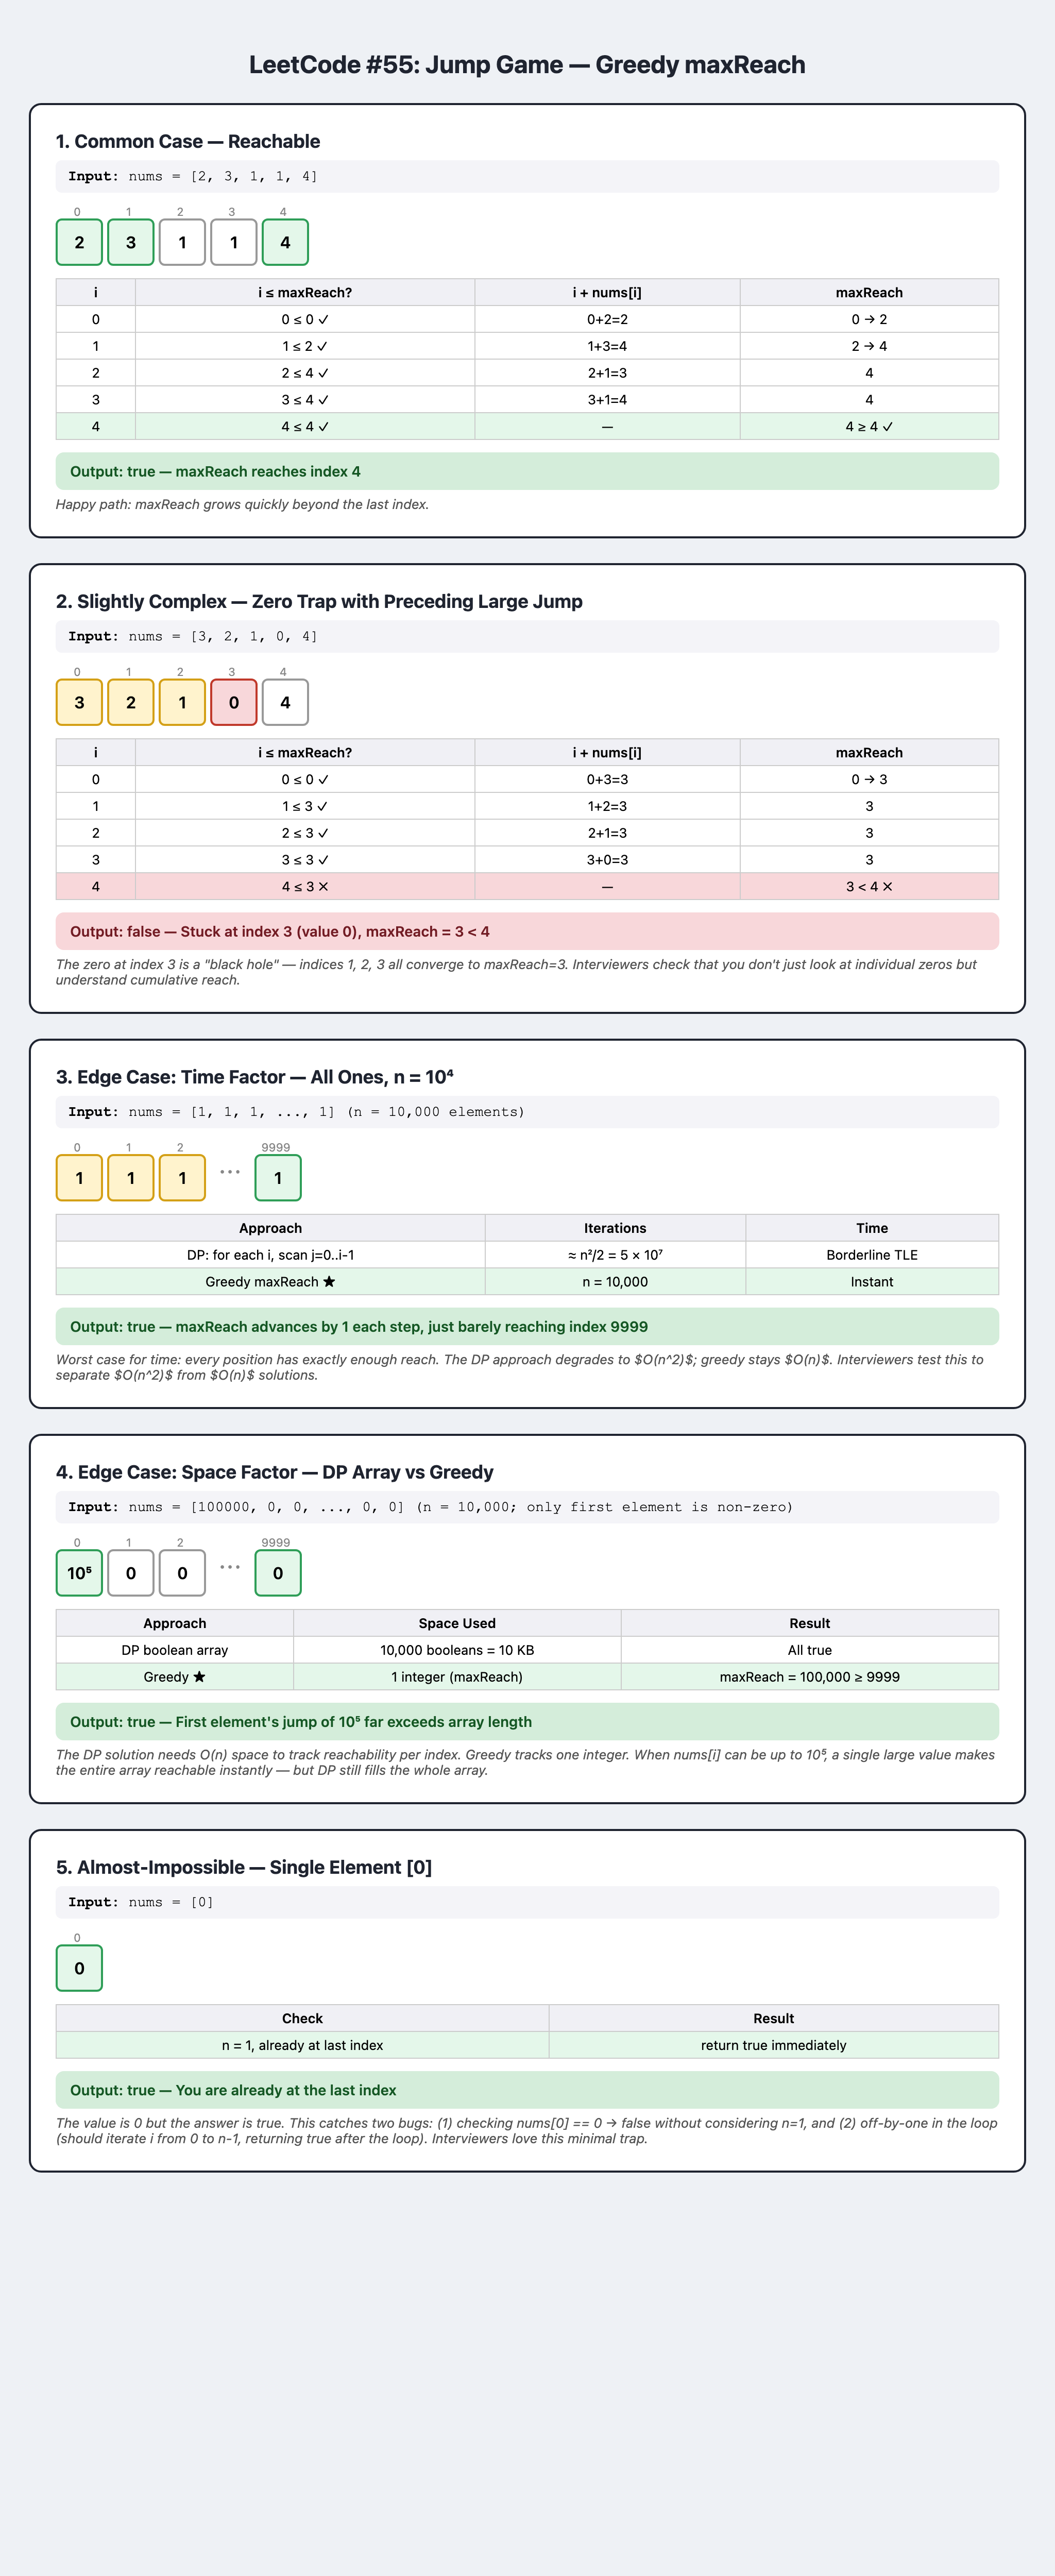